In [5]:
import pandas as pd

df=pd.read_csv("/content/indian_realestate_dataset_1000.csv")

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   property_id                  1000 non-null   object 
 1   city                         1000 non-null   object 
 2   district                     1000 non-null   object 
 3   property_type                1000 non-null   object 
 4   built_up_area_sqft           1000 non-null   int64  
 5   price_inr                    1000 non-null   int64  
 6   price_per_sqft_inr           1000 non-null   int64  
 7   bedrooms                     1000 non-null   int64  
 8   bathrooms                    1000 non-null   int64  
 9   age_years                    1000 non-null   int64  
 10  facing                       1000 non-null   object 
 11  amenities                    1000 non-null   object 
 12  amenities_count              1000 non-null   int64  
 13  walkability_score  

In [3]:
print("Shape:", df.shape)

print("\nDuplicate rows:", df.duplicated().sum())

print("\nMissing values:")
print(df.isnull().sum())

Shape: (1000, 25)

Duplicate rows: 0

Missing values:
property_id                    0
city                           0
district                       0
property_type                  0
built_up_area_sqft             0
price_inr                      0
price_per_sqft_inr             0
bedrooms                       0
bathrooms                      0
age_years                      0
facing                         0
amenities                      0
amenities_count                0
walkability_score              0
monthly_rental_estimate_inr    0
annual_rental_yield_pct        0
price_category                 0
estimated_roi_5yr_pct          0
listing_date                   0
days_on_market                 0
status                         0
registration_days              0
is_gated_community             0
has_maintenance_fee            0
monthly_maintenance_inr        0
dtype: int64


In [6]:
df.describe()

,built_up_area_sqft,price_inr,price_per_sqft_inr,bedrooms,bathrooms,age_years,amenities_count,walkability_score,monthly_rental_estimate_inr,annual_rental_yield_pct,estimated_roi_5yr_pct,days_on_market,registration_days,monthly_maintenance_inr
count,1000.000000,1.000000e+03,1000.000000,1000.00000,1000.000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,3391.764000,2.596963e+07,20668.953000,3.27200,2.121,14.638000,5.528000,7.072000,86510.172000,3.986950,44.934430,180.223000,106.755000,26137.109000
std,2523.685142,1.481749e+07,29689.756367,1.84863,0.877,8.953945,1.747074,1.997199,52175.049467,0.591368,2.957243,104.141426,43.877628,34184.758029
min,252.000000,1.000000e+07,1001.000000,0.00000,1.000,0.000000,3.000000,4.000000,25201.000000,3.000000,40.010000,1.000000,30.000000,0.000000
25%,1247.000000,1.200000e+07,3749.250000,2.00000,1.000,7.000000,4.000000,5.000000,40175.250000,3.447500,42.227500,91.000000,67.000000,0.000000
50%,2898.000000,2.671930e+07,8462.000000,4.00000,2.000,14.000000,6.000000,7.000000,75513.000000,3.980000,44.890000,178.000000,109.500000,0.000000
75%,4997.500000,4.000000e+07,20833.000000,5.00000,3.000,23.000000,7.000000,9.000000,126884.500000,4.512500,47.575000,269.250000,145.000000,60000.000000
max,9997.000000,5.000000e+07,183885.000000,6.00000,4.000,30.000000,8.000000,10.000000,207519.000000,5.000000,49.980000,365.000000,180.000000,100000.000000


In [7]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print("\n" + "=" * 50)
    print("COLUMN:", col)
    print("UNIQUE:", df[col].nunique())
    print(df[col].value_counts().head(20))


COLUMN: property_id
UNIQUE: 1000
property_id
PROP01000    1
PROP00001    1
PROP00002    1
PROP00003    1
PROP00004    1
PROP00005    1
PROP00006    1
PROP00007    1
PROP00984    1
PROP00983    1
PROP00982    1
PROP00981    1
PROP00980    1
PROP00979    1
PROP00978    1
PROP00977    1
PROP00976    1
PROP00975    1
PROP00974    1
PROP00973    1
Name: count, dtype: int64

COLUMN: city
UNIQUE: 6
city
Bangalore    181
Chennai      179
Delhi        166
Pune         165
Mumbai       162
Hyderabad    147
Name: count, dtype: int64

COLUMN: district
UNIQUE: 36
district
South Mumbai     39
Indiranagar      37
Kilpauk          36
Koramangala      35
Besant Nagar     34
Dwarka           34
Jubilee Hills    33
T Nagar          32
Baner            32
South Delhi      32
Jayanagar        31
Marathahalli     31
Viman Nagar      30
Gurgaon          29
Navi Mumbai      28
Bandra           28
Magarpatta       28
Camp             28
Whitefield       28
Banjara Hills    27
Name: count, dtype: int64

COLUMN

In [8]:
y = df["monthly_rental_estimate_inr"]

In [9]:
target = "monthly_rental_estimate_inr"

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

correlation = df[numeric_cols].corr()[target].sort_values(ascending=False)

print(correlation)

monthly_rental_estimate_inr    1.000000
price_inr                      0.958401
monthly_maintenance_inr        0.475032
price_per_sqft_inr             0.356656
annual_rental_yield_pct        0.279338
estimated_roi_5yr_pct          0.279252
age_years                      0.023800
walkability_score              0.011216
amenities_count               -0.016475
bedrooms                      -0.020955
bathrooms                     -0.023241
registration_days             -0.039982
built_up_area_sqft            -0.040610
days_on_market                -0.064448
Name: monthly_rental_estimate_inr, dtype: float64


In [10]:
check_cols = [
    "price_inr",
    "price_per_sqft_inr",
    "annual_rental_yield_pct",
    "estimated_roi_5yr_pct",
    "monthly_maintenance_inr",
    "built_up_area_sqft",
    "bedrooms",
    "bathrooms"
]

print(df[check_cols + ["monthly_rental_estimate_inr"]].corr()["monthly_rental_estimate_inr"].sort_values(ascending=False))

monthly_rental_estimate_inr    1.000000
price_inr                      0.958401
monthly_maintenance_inr        0.475032
price_per_sqft_inr             0.356656
annual_rental_yield_pct        0.279338
estimated_roi_5yr_pct          0.279252
bedrooms                      -0.020955
bathrooms                     -0.023241
built_up_area_sqft            -0.040610
Name: monthly_rental_estimate_inr, dtype: float64


In [11]:
feature_columns = [
    "city",
    "district",
    "property_type",
    "built_up_area_sqft",
    "price_inr",
    "price_per_sqft_inr",
    "bedrooms",
    "bathrooms",
    "age_years",
    "facing",
    "amenities_count",
    "walkability_score",
    "days_on_market",
    "registration_days",
    "is_gated_community",
    "has_maintenance_fee",
    "monthly_maintenance_inr"
]

In [12]:
y = df["monthly_rental_estimate_inr"]

In [13]:
X = df[feature_columns].copy()
y = df["monthly_rental_estimate_inr"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1000, 17)
y shape: (1000,)


In [14]:
print("Numerical Features:")
print(X.select_dtypes(include=["int64", "float64"]).columns.tolist())

print("\nCategorical Features:")
print(X.select_dtypes(include=["object"]).columns.tolist())

print("\nBoolean Features:")
print(X.select_dtypes(include=["bool"]).columns.tolist())

Numerical Features:
['built_up_area_sqft', 'price_inr', 'price_per_sqft_inr', 'bedrooms', 'bathrooms', 'age_years', 'amenities_count', 'walkability_score', 'days_on_market', 'registration_days', 'monthly_maintenance_inr']

Categorical Features:
['city', 'district', 'property_type', 'facing']

Boolean Features:
['is_gated_community', 'has_maintenance_fee']


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (800, 17)
X_test : (200, 17)
y_train: (800,)
y_test : (200,)


In [16]:
numerical_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object"]
).columns.tolist()

boolean_features = X_train.select_dtypes(
    include=["bool"]
).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

print("\nBoolean Features:")
print(boolean_features)

Numerical Features:
['built_up_area_sqft', 'price_inr', 'price_per_sqft_inr', 'bedrooms', 'bathrooms', 'age_years', 'amenities_count', 'walkability_score', 'days_on_market', 'registration_days', 'monthly_maintenance_inr']

Categorical Features:
['city', 'district', 'property_type', 'facing']

Boolean Features:
['is_gated_community', 'has_maintenance_fee']


In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "bool",
            "passthrough",
            boolean_features
        )
    ]
)

print("Preprocessor created successfully.")

Preprocessor created successfully.


In [18]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Lasso

lasso_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(alpha=1.0, max_iter=10000))
    ]
)

print("Lasso pipeline created successfully.")

Lasso pipeline created successfully.


In [19]:
lasso_model.fit(X_train, y_train)

print("Lasso model trained successfully.")

Lasso model trained successfully.


In [20]:
y_pred = lasso_model.predict(X_test)

print(y_pred[:10])

[135737.37832459  94904.60665548  50581.51610258 162114.70257244
 167774.49392902  95923.68295738 160976.06464482 165581.42679094
 130128.05855289  38744.16568208]


In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Lasso Regression")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Lasso Regression
MAE : 11651.22480002706
MSE : 234125837.42949784
RMSE: 15301.17111300628
R²  : 0.9202527276243445


In [23]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV

lasso_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", Lasso(max_iter=20000))
    ]
)

param_grid = {
    "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100, 1000]
}

grid_search = GridSearchCV(
    lasso_pipeline,
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Alpha:", grid_search.best_params_["model__alpha"])
print("Best CV MAE:", -grid_search.best_score_)

Best Alpha: 1000
Best CV MAE: 11336.805405053572


In [24]:
best_lasso = grid_search.best_estimator_

y_pred_tuned = best_lasso.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_tuned)
mse = mean_squared_error(y_test, y_pred_tuned)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_tuned)

print("Tuned Lasso Regression")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Tuned Lasso Regression
MAE : 11560.718206438749
MSE : 228123483.18225327
RMSE: 15103.757253817783
R²  : 0.9222972323415752


In [25]:
best_lasso_model = best_lasso.named_steps["model"]

coefficients = best_lasso_model.coef_

print("Total coefficients:", len(coefficients))
print("Zero coefficients:", np.sum(coefficients == 0))
print("Non-zero coefficients:", np.sum(coefficients != 0))

Total coefficients: 68
Zero coefficients: 65
Non-zero coefficients: 3


In [26]:
print(
    "Percentage of coefficients removed:",
    (np.sum(coefficients == 0) / len(coefficients)) * 100
)

Percentage of coefficients removed: 95.58823529411765


In [27]:
comparison_df = pd.DataFrame({
    "Actual Rent": y_test.values,
    "Predicted Rent": y_pred_tuned,
    "Error": y_test.values - y_pred_tuned
})

comparison_df.head(10)

,Actual Rent,Predicted Rent,Error
0,135984,131486.995798,4497.004202
1,105328,98644.875596,6683.124404
2,51363,50696.185402,666.814598
3,183184,164097.403453,19086.596547
4,199800,165031.943126,34768.056874
5,114155,99345.993947,14809.006053
6,173740,164154.477203,9585.522797
7,185308,164272.896638,21035.103362
8,138059,131195.646340,6863.353660
9,31860,40720.020603,-8860.020603


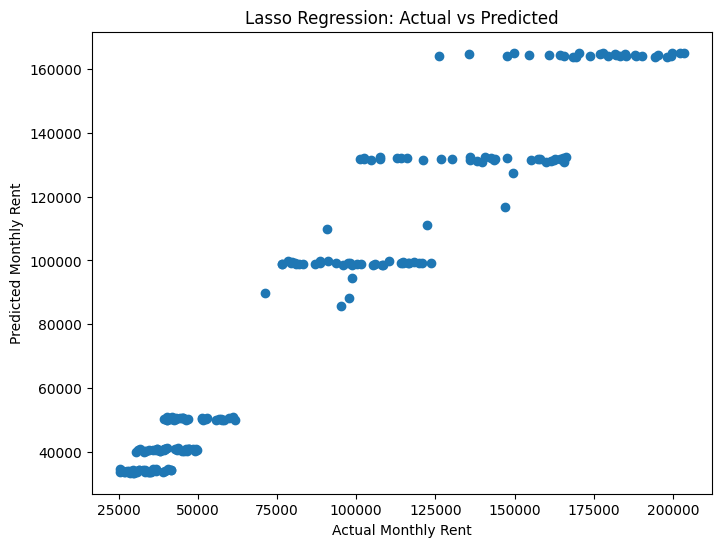

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_tuned)

plt.xlabel("Actual Monthly Rent")
plt.ylabel("Predicted Monthly Rent")
plt.title("Lasso Regression: Actual vs Predicted")

plt.show()

In [29]:
print(X_train.columns.tolist())

['city', 'district', 'property_type', 'built_up_area_sqft', 'price_inr', 'price_per_sqft_inr', 'bedrooms', 'bathrooms', 'age_years', 'facing', 'amenities_count', 'walkability_score', 'days_on_market', 'registration_days', 'is_gated_community', 'has_maintenance_fee', 'monthly_maintenance_inr']


Create 5 New Properties

In [30]:
new_properties = pd.DataFrame({
    "city": [
        "Mumbai",
        "Bangalore",
        "Delhi",
        "Pune",
        "Hyderabad"
    ],
    "district": [
        "South Mumbai",
        "Indiranagar",
        "South Delhi",
        "Baner",
        "Jubilee Hills"
    ],
    "property_type": [
        "Apartment",
        "Villa",
        "Penthouse",
        "Apartment",
        "Independent House"
    ],
    "built_up_area_sqft": [
        1800,
        2500,
        3200,
        1400,
        2200
    ],
    "price_inr": [
        25000000,
        30000000,
        45000000,
        18000000,
        28000000
    ],
    "price_per_sqft_inr": [
        13889,
        12000,
        14063,
        12857,
        12727
    ],
    "bedrooms": [
        3,
        4,
        4,
        2,
        3
    ],
    "bathrooms": [
        2,
        3,
        4,
        2,
        3
    ],
    "age_years": [
        5,
        3,
        2,
        8,
        4
    ],
    "facing": [
        "East",
        "North",
        "West",
        "South",
        "North-East"
    ],
    "amenities_count": [
        6,
        7,
        8,
        5,
        7
    ],
    "walkability_score": [
        8,
        9,
        7,
        8,
        7
    ],
    "days_on_market": [
        60,
        45,
        30,
        90,
        55
    ],
    "registration_days": [
        70,
        60,
        45,
        80,
        65
    ],
    "is_gated_community": [
        True,
        True,
        True,
        False,
        True
    ],
    "has_maintenance_fee": [
        True,
        True,
        True,
        False,
        True
    ],
    "monthly_maintenance_inr": [
        15000,
        20000,
        30000,
        8000,
        18000
    ]
})

print(new_properties)
print("\nShape:", new_properties.shape)

        city       district      property_type  built_up_area_sqft  price_inr  \
0     Mumbai   South Mumbai          Apartment                1800   25000000   
1  Bangalore    Indiranagar              Villa                2500   30000000   
2      Delhi    South Delhi          Penthouse                3200   45000000   
3       Pune          Baner          Apartment                1400   18000000   
4  Hyderabad  Jubilee Hills  Independent House                2200   28000000   

   price_per_sqft_inr  bedrooms  bathrooms  age_years      facing  \
0               13889         3          2          5        East   
1               12000         4          3          3       North   
2               14063         4          4          2        West   
3               12857         2          2          8       South   
4               12727         3          3          4  North-East   

   amenities_count  walkability_score  days_on_market  registration_days  \
0                6    

In [30]:
new_predictions = best_lasso.predict(new_properties)

new_properties["Predicted Monthly Rent"] = new_predictions

new_properties[
    ["city", "property_type", "built_up_area_sqft",
     "bedrooms", "Predicted Monthly Rent"]
]

,city,property_type,built_up_area_sqft,bedrooms,Predicted Monthly Rent
0,Mumbai,Apartment,1800,3,82983.502773
1,Bangalore,Villa,2500,4,99463.558995
2,Delhi,Penthouse,3200,4,147997.084072
3,Pune,Apartment,1400,2,60157.114521
4,Hyderabad,Independent House,2200,3,92590.747411


In [32]:
#  save the model



import joblib

joblib.dump(lasso_model,'Day-05-Real-Estate-Rent-Prediction-Lasso-Regression.pkl')

['Day-05-Real-Estate-Rent-Prediction-Lasso-Regression.pkl']